# Исследование датасета

In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt


data_dir = Path("../data/")


In [2]:
df = pl.read_csv(data_dir / "g5.2xlarge_in_aws_spot_instances.csv")

df = df.with_columns(pl.col("datetime").cast(pl.Datetime), pl.col("cost").cast(pl.Float16))

df

zone,instance,os_type,cost,datetime
str,str,str,f16,datetime[μs]
"""use1-az6""","""g5.2xlarge""","""Linux/UNIX""",0.363525,2022-05-31 19:31:56
"""use1-az1""","""g5.2xlarge""","""Linux/UNIX""",0.363525,2022-05-31 19:31:56
"""use1-az2""","""g5.2xlarge""","""Linux/UNIX""",0.363525,2022-05-31 19:31:56
"""use1-az4""","""g5.2xlarge""","""Linux/UNIX""",0.363525,2022-05-31 19:31:56
"""use1-az5""","""g5.2xlarge""","""Linux/UNIX""",0.363525,2022-05-31 19:31:56
…,…,…,…,…
"""euw1-az2""","""g5.2xlarge""","""Linux/UNIX""",0.596191,2026-02-28 22:46:56
"""sae1-az1""","""g5.2xlarge""","""Linux/UNIX""",0.878906,2026-02-28 23:01:06
"""euw2-az2""","""g5.2xlarge""","""Linux/UNIX""",0.65918,2026-02-28 23:16:24


Судя по данным, сбор временных данных был неравномерным, проверим это через разницу между днями для записей каждого инстанса:

In [3]:
for zone in df["zone"].unique():
    print(f"zone: {zone}")
    scrape_interval = df.filter(pl.col("zone") == zone).sort(pl.col("datetime")).with_columns((pl.col("datetime") - pl.col("datetime").shift(1)).alias("scrape_interval"))["scrape_interval"]
    print(f"max: {scrape_interval.max()}")
    print(f"min: {scrape_interval.min()}")
    print(f"median: {scrape_interval.median()}")
    print("---------------------------")

zone: apne2-az3
max: 11 days, 20:58:32
min: 0:08:47
median: 6:30:01
---------------------------
zone: sae1-az2
max: 31 days, 0:00:00
min: 0:01:32
median: 6:15:05.500000
---------------------------
zone: use1-az6
max: 31 days, 0:00:00
min: 0:05:06
median: 6:14:51
---------------------------
zone: aps1-az3
max: 31 days, 0:00:00
min: 0:01:15
median: 6:15:02
---------------------------
zone: mec1-az2
max: 8 days, 18:26:52
min: 0:01:03
median: 6:08:50
---------------------------
zone: ilc1-az2
max: 1 day, 0:00:57
min: 0:00:12
median: 5:59:36.500000
---------------------------
zone: euw1-az2
max: 31 days, 0:00:00
min: 0:01:39
median: 6:14:25
---------------------------
zone: apne2-az1
max: 4 days, 2:12:04
min: 0:01:00
median: 6:15:01
---------------------------
zone: euc1-az1
max: 31 days, 0:00:00
min: 0:16:20
median: 6:15:03
---------------------------
zone: ape1-az2
max: 13:45:02
min: 0:45:00
median: 6:14:57
---------------------------
zone: usw2-az1
max: 31 days, 0:00:00
min: 0:01:11
medi

Так и получилось, судя по медиане, наши данные чаще всего меняются раз в 6 часов. Судя из кода обработки, он получает данные только при изменении, если нет записи, то цена осталась прежней.

### Изучим cost

Сначала узнаем высшую границу цены инстанса за аренду с неизменяемой ценой. Для этого возьмем данный датасет [AWS EC2 Instance Comparison](https://www.kaggle.com/datasets/berkayalan/aws-ec2-instance-comparison) и получим цену нашего `g5.2xlarge`

In [4]:
(pl.read_csv(data_dir / "amazon_instances.csv", null_values=["N/A", "N/a", "na", "-", ""], ignore_errors=True)
 .filter(pl.col("API Name") == "g5.2xlarge")
 .select(["API Name", "Linux On Demand cost"]))

API Name,Linux On Demand cost
str,str
"""g5.2xlarge""","""$1.212 hourly"""


Получается высшая граница 1.212 $ в час, посмотрим теперь в нашем датасете.

In [5]:
df["cost"].describe()

statistic,value
str,f64
"""count""",147210.0
"""null_count""",0.0
"""mean""",0.540527
"""std""",0.158936
"""min""",0.14209
"""25%""",0.449463
"""50%""",0.520508
"""75%""",0.608398
"""max""",1.779297


Странно, тут max выше, смотрим, сколько вообще таких выбросов

In [6]:
ON_DEMAND_PRICE = 1.212

print(df.filter(pl.col("cost") > ON_DEMAND_PRICE).shape)

df.filter(pl.col("cost") > ON_DEMAND_PRICE).describe()


(1255, 5)


statistic,zone,instance,os_type,cost,datetime
str,str,str,str,f64,str
"""count""","""1255""","""1255""","""1255""",1255.0,"""1255"""
"""null_count""","""0""","""0""","""0""",0.0,"""0"""
"""mean""",null,null,null,1.416016,"""2025-04-11 02:55:11.137051"""
"""std""",null,null,null,0.112366,null
"""min""","""ape1-az1""","""g5.2xlarge""","""Linux/UNIX""",1.212891,"""2023-06-26 19:22:32"""
"""25%""",null,null,null,1.31543,"""2024-11-11 06:51:18"""
"""50%""",null,null,null,1.458984,"""2025-06-16 10:08:43"""
"""75%""",null,null,null,1.490234,"""2025-11-20 21:01:14"""
"""max""","""sae1-az1""","""g5.2xlarge""","""Linux/UNIX""",1.779297,"""2026-02-06 02:16:24"""


Погуглив, оказалось, что ON_SPOT цена может превысить цену ON_DEMAND при резком спросе))) . Следовательно ограничивать данные верхней границей ON_DEMAND_PRICE нецелесобразно.

### Исследование цены

Проведем сэмплирование на 6 часа, после объединим зоны и будем показывать худшую цену за 6 часов

In [7]:
df_resampled = (
    df
    .with_columns(
        pl.col("datetime").dt.truncate("6h").alias("datetime")
    )
    .group_by("datetime")
    .agg(pl.col("cost").max())
    .sort("datetime")
)

# 2. заполняем пропуски равномерной сеткой
df_6h = (
    df_resampled
    .upsample("datetime", every="6h")
    .with_columns(pl.col("cost").forward_fill())
)

df_6h.write_parquet(data_dir / "g5_2xlarge_6h.parquet")
print(f"saved 6h: {df_6h.shape}")
df_6h.head()

saved 6h: (5477, 2)


datetime,cost
datetime[μs],f16
2022-05-31 18:00:00,0.363525
2022-06-01 00:00:00,0.533691
2022-06-01 06:00:00,0.537598
2022-06-01 12:00:00,0.540527
2022-06-01 18:00:00,0.541016


In [8]:
df_6h = pl.read_parquet(data_dir / "g5_2xlarge_6h.parquet")
df_6h.head()

datetime,cost
datetime[μs],f16
2022-05-31 18:00:00,0.363525
2022-06-01 00:00:00,0.533691
2022-06-01 06:00:00,0.537598
2022-06-01 12:00:00,0.540527
2022-06-01 18:00:00,0.541016


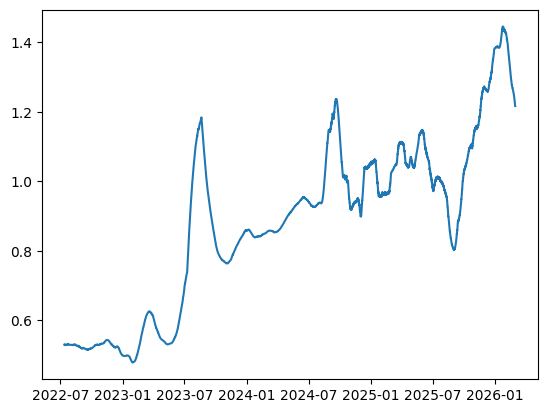

In [9]:
df_smooth = df_6h.with_columns(
    pl.col("cost").rolling_mean(window_size=24*7).alias("cost_smooth")
)
plt.plot(df_smooth["datetime"], df_smooth["cost_smooth"])

Видим с 2023-07 взлет цены, это связано с бумом AI и возрастанием потребности в GPU. Следовательно рынок сменился, поэтому данные неактуальны, их мы отсечем до 2024-07.

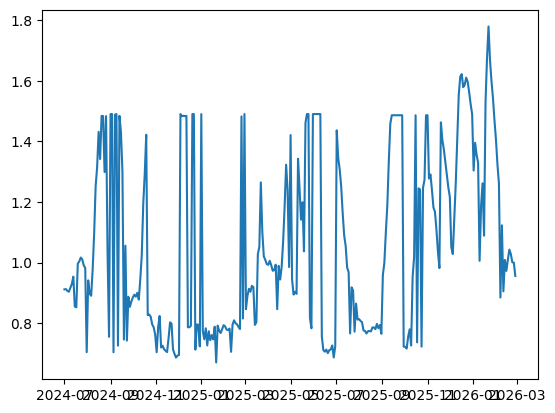

In [10]:
from datetime import datetime

to_the_moon = df_6h.filter(pl.col("datetime") >= pl.lit("2024-07-01").str.to_datetime())

plt.plot(to_the_moon["datetime"][::8], to_the_moon["cost"][::8])

Другое дело, тут уже и сезонность какая то проглядывается и какие то паттерны схожие. Сохраним это

In [11]:
df_6h.filter(pl.col("datetime") >= pl.lit("2024-07-01").str.to_datetime()).write_parquet(data_dir / "g5_2xlarge_6h_after_2024-07.parquet")